In [1]:

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import re
import json
from glob import glob
from PIL import Image
import torchvision.transforms as T
import cv2
import dlib
import torch
# from imutils.face_utils import FaceAligner
import imutils
from tqdm.notebook import tqdm # Utilise tqdm.notebook pour un affichage adapté
from collections import Counter
import os

from torchvision import datasets, transforms
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import torchvision.transforms.functional as F
from PIL import Image
import pytesseract
from pytesseract import Output

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.gridspec import GridSpec

In [2]:
# Définition des chemins d'entrée et de sortie
# Les datasets Kaggle sont montés ici
INPUT_DIR = '/kaggle/input/anip-reconnaissance-faciale-estimation-ages-ocr/dataset_tache_3/dataset_tache_3'
TRAIN_DIR = os.path.join(INPUT_DIR, 'train')
TEST_DIR = os.path.join(INPUT_DIR, 'test')

# Seul le répertoire /kaggle/working/ est inscriptible
OUTPUT_DIR = '/kaggle/working'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dtype = torch.float16 if torch.cuda.is_available() else torch.float32

# Task 3: OCR & Fraud Detection

## Prétraitement de données (Expérimentations)

In [3]:
# Fonction pour compter les fichiers par pays et catégorie
def count_files(train_dir):
    data = []
    countries = sorted(os.listdir(train_dir))  # e.g., ['arizona_dl', 'estonia_id', 'russia_passport', 'spain_id']
    for country in countries:
        country_path = os.path.join(train_dir, country)
        subdirs = sorted(os.listdir(country_path))  # e.g., ['forgery_1', 'forgery_2', 'forgery_3', 'forgery_4', 'gt', 'normal']
        for subdir in subdirs:
            subdir_path = os.path.join(country_path, subdir)
            files = [f for f in os.listdir(subdir_path) if f.endswith('.png') or f.endswith('.json')]
            data.append({'country': country, 'category': subdir, 'num_files': len(files)})
    df = pd.DataFrame(data)
    return df

In [4]:
# Aperçu des données
df_counts = count_files(TRAIN_DIR)
print("Aperçu des comptages :")
print(df_counts.pivot(index='country', columns='category', values='num_files'))

Aperçu des comptages :
category    forgery_1  forgery_2  forgery_3  forgery_4   gt  normal
country                                                            
arizona_dl        500        500        500        500  500     500
esp               500        500        500        500  500     500
est               500        500        500        500  500     500
rus               500        500        500        500  500     500


In [5]:
# Fonction pour charger et valider un GT JSON par pays
def load_gt_json(gt_path, country):
    with open(gt_path, 'r', encoding='utf-8') as f:  # UTF-8 pour cyrillique/accents
        data = json.load(f)
    expected_fields = FIELD_MAPPERS.get(country, [])
    missing = [f for f in expected_fields if f not in data.get('root', data)]  # Handle 'root' ou flat
    if missing:
        print(f"Champs manquants pour {country}: {missing}")
    return data

# # Exemple : Charger un sample par pays (adapter noms de fichiers)
# sample_gts = {}
# countries = ['arizona_dl', 'esp', 'est', 'rus']  # Adapter noms dossiers
# for country in countries:
#     gt_dir = os.path.join(TRAIN_DIR, country, 'gt')
#     sample_file = os.listdir(gt_dir)[0]  # Premier JSON
#     sample_path = os.path.join(gt_dir, sample_file)
#     sample_gts[country] = load_gt_json(sample_path, country)
#     print(f"GT sample pour {country}: {json.dumps(sample_gts[country], indent=4, ensure_ascii=False)}")  # ensure_ascii pour cyrillique


In [6]:
from PIL import Image

img = Image.open("/kaggle/input/anip-reconnaissance-faciale-estimation-ages-ocr/dataset_tache_3/dataset_tache_3/train/arizona_dl/normal/generated.photos_v3_0090599.png")
print("Taille originale :", img.size)  # (width, height)


Taille originale : (600, 375)


### Ecart-Type et Moyenne de chaque ensemble pour potentiel Normalization

In [7]:
# # Transforms sans Normalize
# transform = transforms.Compose([
#     transforms.Resize((224, 224)),
#     transforms.ToTensor()
# ])

# def custom_dataset(root, exclude=['gt']):
#     data = []
#     classes = [d for d in os.listdir(root) if os.path.isdir(os.path.join(root, d)) and d not in exclude]
#     class_to_idx = {cls_name: idx for idx, cls_name in enumerate(classes)}

#     for cls in classes:
#         cls_path = os.path.join(root, cls)
#         for fname in os.listdir(cls_path):
#             fpath = os.path.join(cls_path, fname)
#             if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
#                 data.append((fpath, class_to_idx[cls]))

#     return [(transform(Image.open(path).convert('RGB')), label) for path, label in data]

# dataset = custom_dataset(
#     root='/kaggle/input/anip-reconnaissance-faciale-estimation-ages-ocr/dataset_tache_3/dataset_tache_3/train/arizona_dl'
# )
# loader = DataLoader(dataset, batch_size=64, shuffle=False)

# mean = 0.
# std = 0.
# nb_samples = 0

# for data, _ in loader:
#     batch_samples = data.size(0)
#     data = data.view(batch_samples, data.size(1), -1)
#     mean += data.mean(2).sum(0)
#     std += data.std(2).sum(0)
#     nb_samples += batch_samples

# mean /= nb_samples
# std /= nb_samples

# print("Mean:", mean)
# print("Std:", std)


Moyenne et Ecart-Type de l'ensemble de chaque type de carte sous de tensor --> 3D

1. Arizona_dl Mean: tensor([0.7411, 0.6710, 0.5745])
Std: tensor([0.1637, 0.1479, 0.1344])

2. ESP Mean: tensor([0.6844, 0.6937, 0.6851])
Std: tensor([0.1440, 0.1441, 0.2023])

3. EST Mean: tensor([0.7556, 0.7614, 0.7815])
Std: tensor([0.1656, 0.1571, 0.1695])


4. RUS Mean: tensor([0.8838, 0.8236, 0.7965])
Std: tensor([0.1282, 0.1504, 0.1511])

### Quelques Tests de prétraitement d'images

In [8]:
# Preprocessing functions spécifiques par pays
def get_preprocess(country):
    base_transforms = [
        transforms.Resize((700, 1084)),
        #transforms.GaussianBlur(kernel_size=3),
        transforms.ToTensor(),
        #transforms.Normalize(mean=[0.5], std=[0.5])
    ]
    if country == 'arizona_dl':
        # US DL: Grayscale, contrast boost pour textes fins
        return transforms.Compose([
            #transforms.Grayscale(num_output_channels=1), 
            transforms.ColorJitter(contrast=0.5)
        ] + base_transforms)
    elif country == 'esp':
        # Espagne : garder couleur + léger sharpen
        sharpen_transform = transforms.Lambda(lambda img: F.adjust_sharpness(img, sharpness_factor=1.5))
        return transforms.Compose([sharpen_transform] + base_transforms)
    elif country == 'est':
        # Estonie: Grayscale, brightness adjust pour fonds clairs
        return transforms.Compose([
            #transforms.Grayscale(num_output_channels=1), 
            transforms.ColorJitter(brightness=0.3)
        ] + base_transforms)
    elif country == 'rus':
        # Russie: Garder couleur pour cyrillique coloré, higher blur pour noise
        return transforms.Compose([
            #transforms.GaussianBlur(kernel_size=5)
        ] + base_transforms)
    else:
        return transforms.Compose(base_transforms)  # Default

# Fonction pour collecter des samples par pays/catégorie (e.g., 3 par catégorie pour visu)
def collect_samples(country, categories=['normal', 'forgery_1', 'forgery_2', 'forgery_3', 'forgery_4'], num_samples=3):
    samples = {}
    for cat in categories:
        cat_dir = os.path.join(TRAIN_DIR, country, cat)
        files = [f for f in os.listdir(cat_dir) if f.endswith('.png')]
        selected = files[:num_samples]  # Prendre les premiers
        samples[cat] = [os.path.join(cat_dir, f) for f in selected]
    return samples

# Fonction pour preprocess en batch (retourne liste de tensors, sans save)
def batch_preprocess(image_paths, country):
    preprocess_fn = get_preprocess(country)
    processed = []
    for path in image_paths:
        img = Image.open(path).convert('RGB')
        img_tensor = preprocess_fn(img)
        processed.append(img_tensor)
    return processed  # Liste de tensors (peut stacker si besoin: torch.stack(processed))


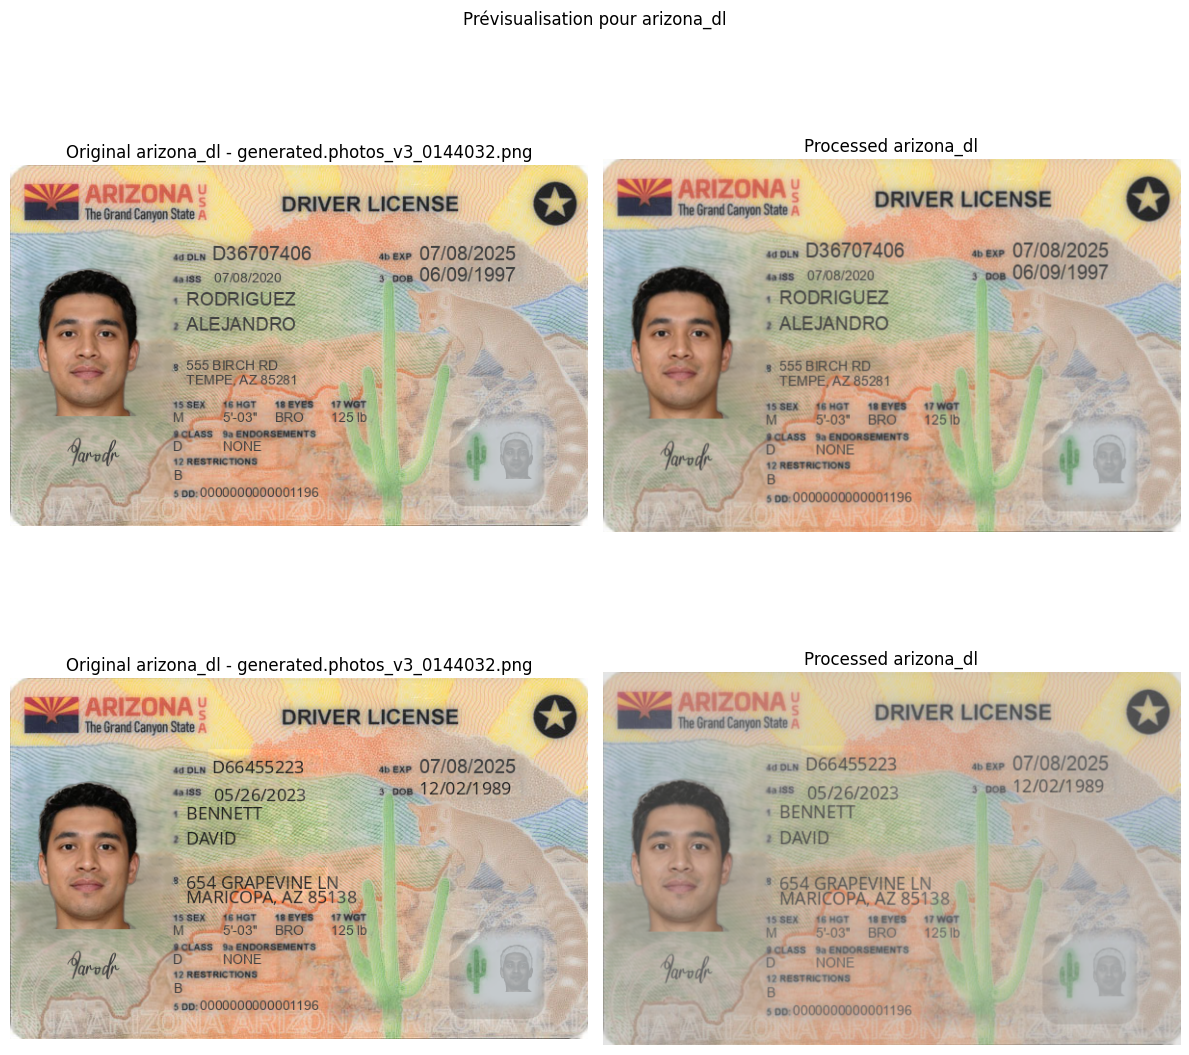

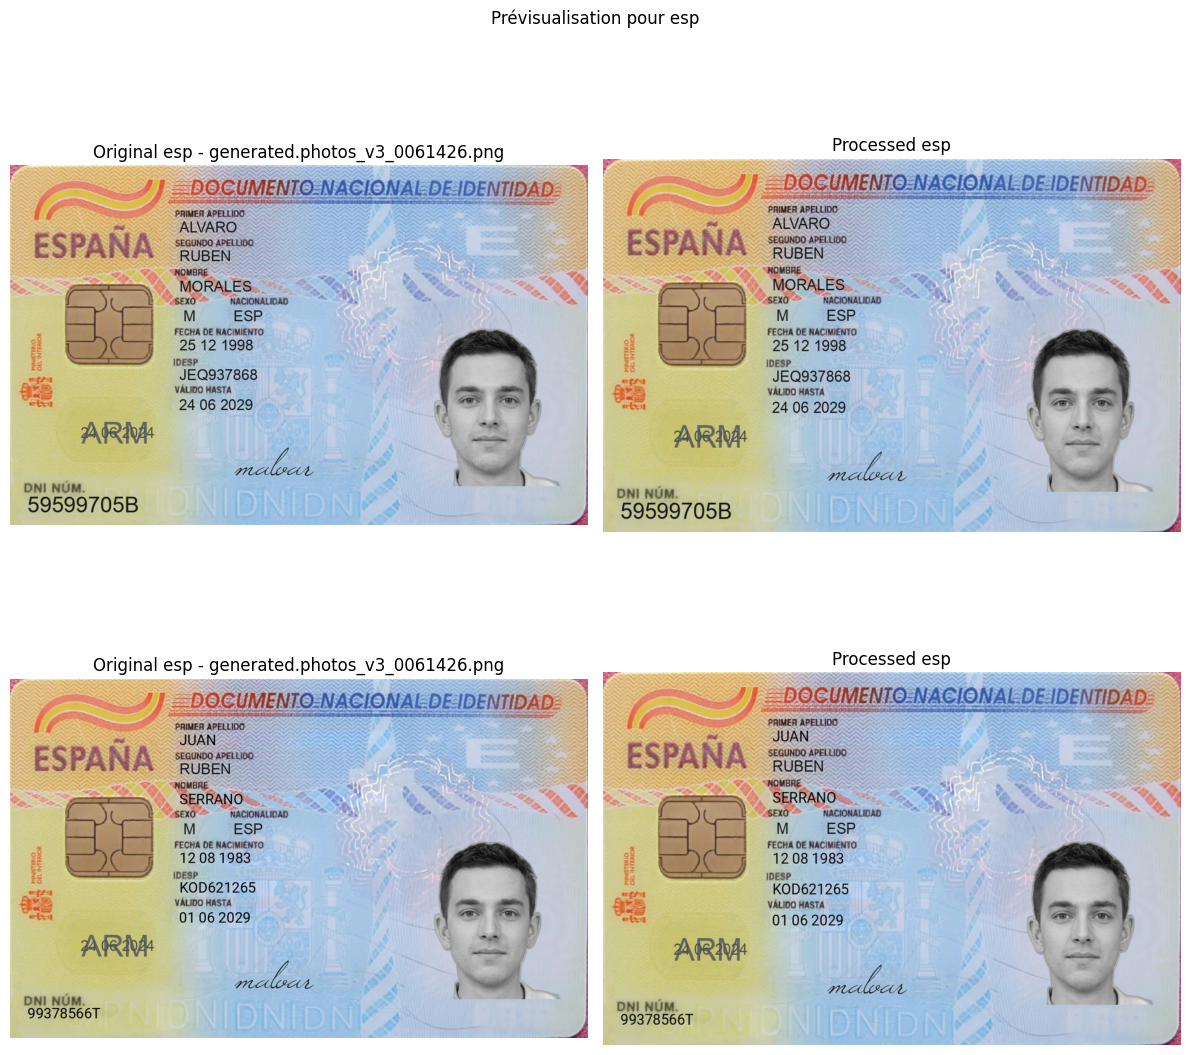

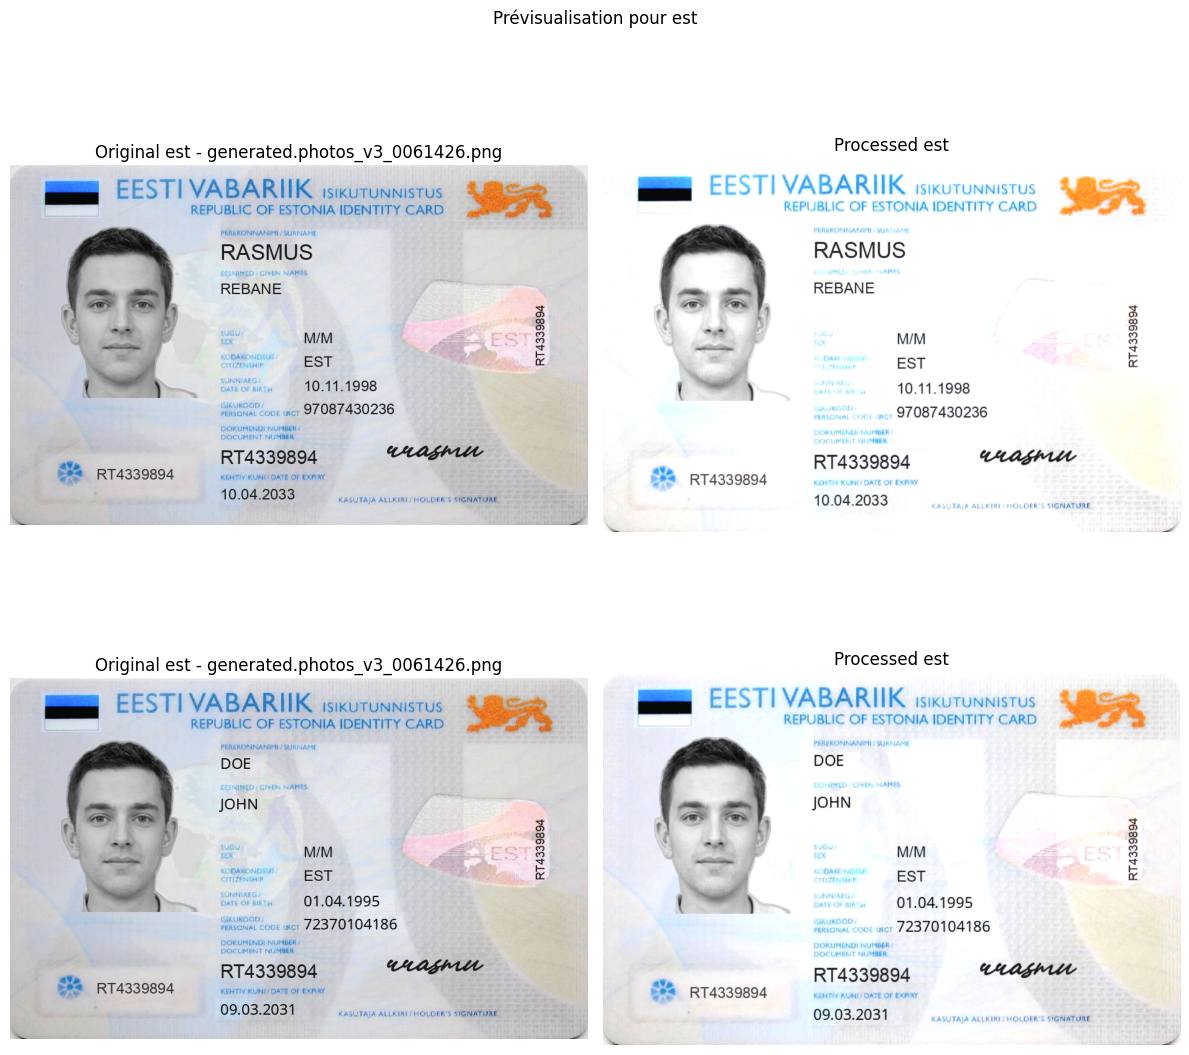

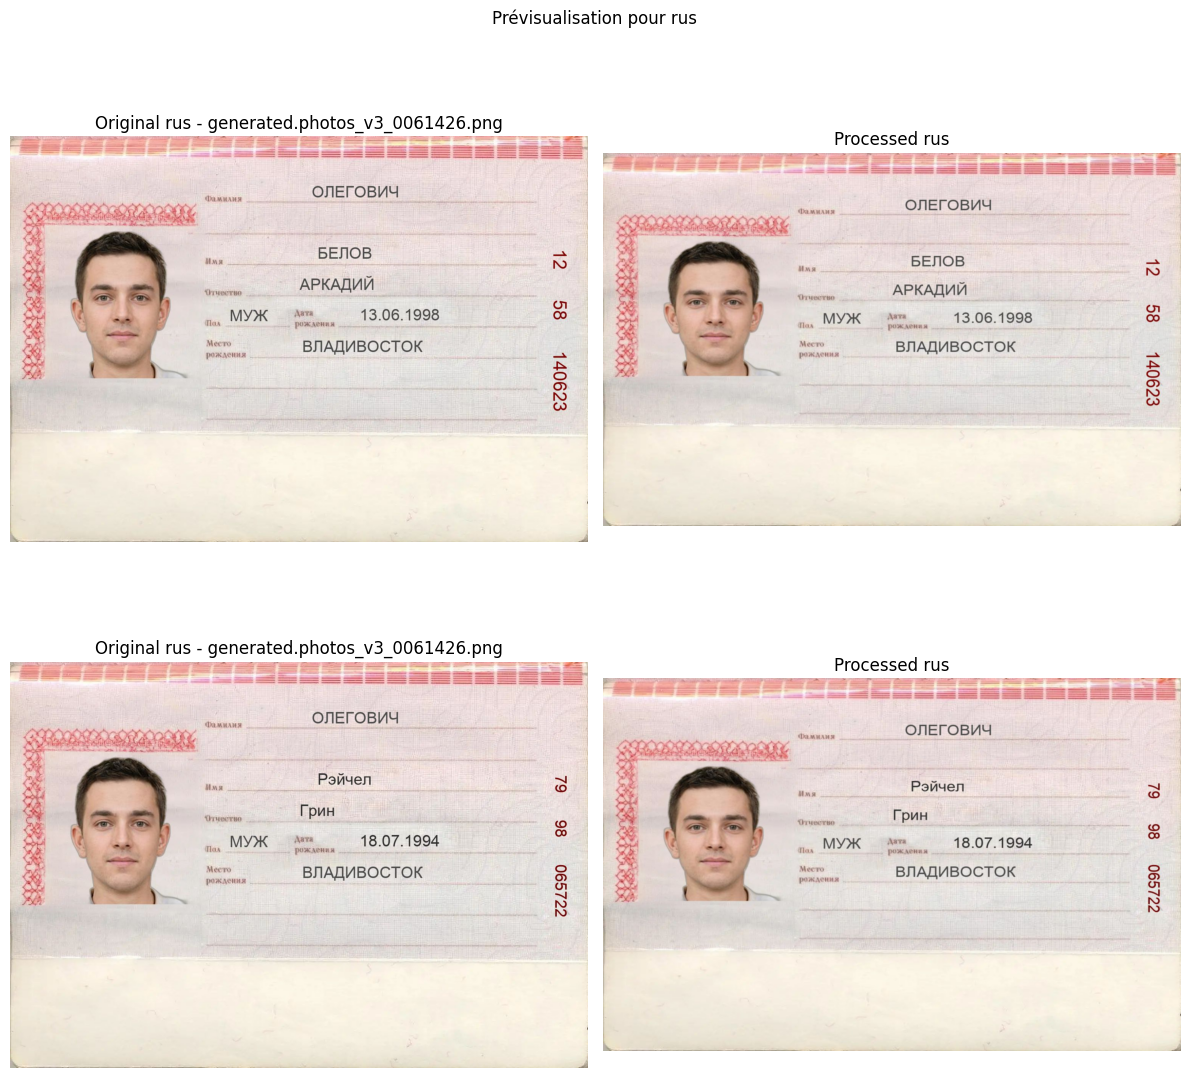

In [9]:
# Fonction de visualisation multi-pays/multi-samples
def preview_multi_samples(countries, categories=['normal', 'forgery_1', 'forgery_2', 'forgery_3', 'forgery_4'], num_samples=3):
    for country in countries:
        samples = collect_samples(country, categories, num_samples)
        all_original_paths = [path for cat_paths in samples.values() for path in cat_paths]
        all_processed = []
        for cat in categories:
            processed = batch_preprocess(samples[cat], country)
            all_processed.extend(processed)
        
        # Visualisation
        num_images = len(all_original_paths)
        fig = plt.figure(figsize=(12, 6 * (num_images // 2 + 1)))
        gs = GridSpec(num_images, 2, figure=fig)  # 2 colonnes: original + processed
        
        for i, (orig_path, proc_tensor) in enumerate(zip(all_original_paths, all_processed)):
            # Original
            ax_orig = fig.add_subplot(gs[i, 0])
            original = Image.open(orig_path)
            ax_orig.imshow(original)
            ax_orig.set_title(f'Original {country} - {os.path.basename(orig_path)}')
            ax_orig.axis('off')
            
            # Processed (convert tensor to PIL pour imshow)
            proc_img = transforms.ToPILImage()(proc_tensor)
            ax_proc = fig.add_subplot(gs[i, 1])
            ax_proc.imshow(proc_img, cmap='gray' if proc_tensor.shape[0] == 1 else None)  # Grayscale si 1 channel
            ax_proc.set_title(f'Processed {country}')
            ax_proc.axis('off')
        
        plt.suptitle(f'Prévisualisation pour {country}')
        plt.tight_layout()
        plt.show()

# Exemple d'utilisation
countries = ['arizona_dl', 'esp', 'est', 'rus']
preview_multi_samples(countries, categories=['normal', 'forgery_1'], num_samples=1) 

## 1. Constants

In [10]:
IMG_EXT = ('.png', '.jpg', '.jpeg')

OCR_LANGS = {
    'arizona_dl': 'eng',
    'esp': 'spa',
    'est': 'est',
    'rus': 'rus'
}

# Mapping des champs attendus par pays/types de carte
FIELD_MAPPERS = {
    'arizona_dl': ['name', 'address', 'birthday', 'gender', 'class', 'issue_date', 'expire_date', 'license_number', 'height', 'weight', 'eye_color', 'DD'],
    'esp': ['country_code', 'surname', 'given_name', 'birthday', 'issue_date', 'expire_date', 'gender', 'second_surname', 'card_num', 'personal_num'],  
    'est': ['type', 'country_code', 'country', 'surname', 'given_name', 'birthday', 'gender', 'issue_date', 'expire_date', 'place_of_birth', 'issue_authority', 'personal_num', 'card_num'],
    'rus': ['country_code', 'surname', 'given_name', 'birthday', 'issue_date', 'expire_date', 'gender', 'patronymic_name', 'place_of_birth', 'card_num']
}

##  2. Preprocessing

In [11]:
def get_preprocess(country):
    base = [
        transforms.Resize((700, 1084)),
        transforms.ToTensor(),
    ]
    if country == 'arizona_dl':
        return transforms.Compose([transforms.ColorJitter(contrast=0.5)] + base)
    elif country == 'esp':
        import torchvision.transforms.functional as F
        sharpen = transforms.Lambda(lambda img: F.adjust_sharpness(img, 1.5))
        return transforms.Compose([sharpen] + base)
    elif country == 'est':
        return transforms.Compose([transforms.ColorJitter(brightness=0.3)] + base)
    elif country == 'rus':
        return transforms.Compose(base)  # garder couleur pour cyrillique
    else:
        return transforms.Compose(base)


## 3. Datasets

### 3.1 Image-only Dataset

In [12]:
class CountryForgeryDataset(Dataset):
    """
    Dataset image‐only. Retourne (tensor_image, label_str, filename).
    """
    def __init__(self,
                 root_country: str,
                 preprocess: transforms.Compose,
                 include_classes=('normal','forgery_1','forgery_2','forgery_3','forgery_4')):
        self.samples = []
        self.preprocess = preprocess

        for cls in include_classes:
            cls_dir = os.path.join(root_country, cls)
            if not os.path.isdir(cls_dir): 
                continue
            for fname in os.listdir(cls_dir):
                if fname.lower().endswith(IMG_EXT):
                    full = os.path.join(cls_dir, fname)
                    self.samples.append((full, cls, fname))

        # Index par nom pour appariement ultérieur
        self.by_name = {}
        for path, cls, fname in self.samples:
            self.by_name.setdefault(fname, []).append((path, cls))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, cls, fname = self.samples[idx]
        img = Image.open(path).convert('RGB')
        x   = self.preprocess(img)
        y   = cls  # à mapper en int si besoin
        return x, y, fname

### 3.2 Multimodal Dataset (Image + OCR JSON)

In [13]:
class MultimodalForgeryDataset(Dataset):
    """
    Dataset multimodal. Retourne (img_tensor, text_feat, label_int).
    text_feat est un vecteur binaire de présence/absence de chaque champ.
    """
    def __init__(self,
                 root_country: str,
                 country_key: str,
                 preprocess: transforms.Compose,
                 ocr_engine,               # instance de modèle OCR
                 field_mappers: dict,
                 exclude=('gt',)):
        self.samples = []
        self.country       = country_key
        self.preprocess    = preprocess
        self.ocr_engine    = ocr_engine
        self.field_mappers = field_mappers

        classes = [d for d in os.listdir(root_country)
                   if os.path.isdir(os.path.join(root_country, d))
                   and d not in exclude]
        self.class_to_idx = {cls: idx for idx, cls in enumerate(classes)}

        for cls in classes:
            cls_path = os.path.join(root_country, cls)
            for fname in os.listdir(cls_path):
                if fname.lower().endswith(IMG_EXT):
                    fpath = os.path.join(cls_path, fname)
                    self.samples.append((fpath, self.class_to_idx[cls]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        img_tensor = self.preprocess(img)

        # OCR → JSON structuré
        ocr_json, raw_text = self.ocr_engine.extract(path,
                                           self.country,
                                           self.field_mappers)
        return img_tensor, ocr_json, raw_text, label

## 4. OCR Engine: Florence 2 Wrapper

In [14]:
!uv pip install transformers==4.49.0

Using Python 3.11.13 environment at: /usr
Resolved 29 packages in 453ms                                        
⠙ Preparing packages... (0/2)                                                   
⠙ Preparing packages... (0/2)---------     0 B/551.04 KiB               
⠙ Preparing packages... (0/2)--------- 16.00 KiB/551.04 KiB             
⠙ Preparing packages... (0/2)--------- 32.00 KiB/551.04 KiB             
⠙ Preparing packages... (0/2)--------- 48.00 KiB/551.04 KiB             
⠙ Preparing packages... (0/2)--------- 63.38 KiB/551.04 KiB             
huggingface-hub ------------------------------ 63.38 KiB/551.04 KiB
⠙ Preparing packages... (0/2)------     0 B/9.51 MiB                    
huggingface-hub ------------------------------ 63.38 KiB/551.04 KiB
⠙ Preparing packages... (0/2)------ 14.90 KiB/9.51 MiB                  
huggingface-hub ------------------------------ 63.38 KiB/551.04 KiB
⠙ Preparing packages... (0/2)------ 30.90 KiB/9.51 MiB                  
huggingface-hub ---

In [15]:
from huggingface_hub import login
from kaggle_secrets import UserSecretsClient

HF_TOKEN = UserSecretsClient().get_secret("HF_TOKEN")
login(token=HF_TOKEN)

In [41]:
import re

# Patterns regex par pays pour chaque champ de FIELD_MAPPERS
REGEX_PATTERNS = {
    'arizona_dl': {
        'name':            r"\d{2}/\d{2}/\d{4}\s+([A-Z][A-Z\s]+?)(?=\s+DOB)",
        'address':         r"(\d{1,5}\s[A-Z0-9\s,\.]+?)(?=\s+(?:EXP|ISS|DOB|SEX))",
        'birthday':        r"DOB\D*([0-9]{2}/[0-9]{2}/[0-9]{4})",
        'gender':          r"SEX\D*([MF])",
        'class':           r"CLASS\D*([A-Z0-9]+)",
        'issue_date':      r"ISS\D*([0-9]{2}/[0-9]{2}/[0-9]{4})",
        'expire_date':     r"EXP\D*([0-9]{2}/[0-9]{2}/[0-9]{4})",
        'license_number':  r"DLN[D]?\D*([0-9]+)",
        'height':          r"HGT\D*([0-9]-[0-9]{2})",
        'weight':          r"WGT\D*([0-9]{2,3})",
        'eye_color':       r"EYES?\D*([A-Z]{2,3})",
        'DD':              r"DD?[:\s]*([0-9]+)"
    },
    'esp': {
        'country_code':    r"(ESPANA)",
        'surname':         r"PRIMER\s+APELLIDO\s*([A-ZÑ]+)",
        'second_surname':  r"SEGUNDO\s+APELLIDO\s*([A-ZÑ]+)",
        'given_name':      r"NOMBRE\s*([A-ZÑ]+)",
        'birthday':        r"FECHA\s+DE\s+NACIMIENTO\s*([0-9]{2}\s?[0-9]{2}\s?[0-9]{4})",
        'issue_date':      r"EXPEDICIÓN\s*([0-9]{2}\s?[0-9]{2}\s?[0-9]{4})",
        'expire_date':     r"HASTA\s*([0-9]{2}\s?[0-9]{2}\s?[0-9]{4})",
        'gender':          r"SEXO\s*([A-Z]+)",
        'card_num':        r"IDESP([A-Z0-9]+)",
        'personal_num':    r"DNI\s+N[ÚU]M[^\d]*(\d+)"
    },
    'est': {
        'type':            r"(ISIKUTUNNISTUS)",
        'country_code':    r"(EESTI)",
        'country':         r"REPUBLIC\s+OF\s*([A-Z][a-z]+)",
        'surname':         r"SURNAME\s*([A-Z]+)",
        'given_name':      r"GIVEN\s+NAME\s*([A-Z]+)",
        'birthday':        r"DATE\s+OF\s+BIRTH\s*([0-9]{2}\.[0-9]{2}\.[0-9]{4})",
        'gender':          r"SUGU\/N\/F\s*([MF])",
        'issue_date':      r"DATE\s+OF\s+ISSUE\s*([0-9]{2}\.[0-9]{2}\.[0-9]{4})",
        'expire_date':     r"DATE\s+OF\s+EXPIRY\s*([0-9]{2}\.[0-9]{2}\.[0-9]{4})",
        'place_of_birth':  r"PLACE\s+OF\s+BIRTH\s*([A-Za-z\s]+)",
        'issue_authority': r"ISSUING\s+AUTHORITY\s*([A-Za-z\s]+)",
        'personal_num':    r"PERSONAL\s+CODE\s*([A-Z0-9]+)",
        'card_num':        r"DOCUMENT\s+NUMBER\s*([A-Z0-9]+)"
    },
    'rus': {
        'country_code':    r"(РОССИЯ)",
        'surname':         r"^([А-ЯЁ]{2,})(?=[А-ЯЁ]+\.)",
        'given_name':      r"ФИО\.\s*([А-ЯЁ]+)",
        'birthday':        r"(\d{2}\.\d{2}\.\d{4})",
        'issue_date':      r"Issue\s+Date[:\s]*([0-9]{2}\.[0-9]{2}\.[0-9]{4})",
        'expire_date':     r"Expiry\s+Date[:\s]*([0-9]{2}\.[0-9]{2}\.[0-9]{4})",
        'gender':          r"Пол[а]?[:\s]*([МЖ])",
        'patronymic_name': r"([А-ЯЁ]+)(?=ОВИЧ|ОВНА)",
        'place_of_birth':  r"Place\s+of\s+Birth[:\s]*([А-ЯЁ\s]+)",
        'card_num':        r"([0-9A-Z]{9,})"
    }
}

In [42]:
from transformers import AutoProcessor, AutoModelForCausalLM

class FlorenceOCR:
    def __init__(self, model_name: str="microsoft/Florence-2-large-ft", device: str=None):
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        self.dtype = torch.float16 if torch.cuda.is_available() else torch.float32
        self.model = AutoModelForCausalLM.from_pretrained(
            model_name, torch_dtype=self.dtype, 
            trust_remote_code=True,
            revision="refs/pr/38"
        ).to(self.device)
        self.processor = AutoProcessor.from_pretrained(
            model_name, 
            trust_remote_code=True,
            revision="refs/pr/38"
        )

        # # Ajout de special tokens pour OCR et langues
        # new_tokens = ["<JSON>", "<eng>", "<spa>", "<est>", "<rus>"]
        # self.processor.tokenizer.add_special_tokens(
        #     {'additional_special_tokens': new_tokens}
        # )
        # self.model.resize_token_embeddings(len(self.processor.tokenizer))

    # def build_prompt(self, country: str, fields: list[str]):
    #     lang_token = {
    #         'arizona_dl': 'eng',
    #         'esp':        'spa',
    #         'est':        'est',
    #         'rus':        'rus'
    #     }[country]

    #     return (
    #         f"Language: {lang_token}"
    #         f"You are a document OCR system for {country} ID cards.\n"
    #         f"Extract exactly these fields and return a valid JSON:\n"
    #         f"{fields}\n"
    #         f"If a field is missing or unreadable, set it to null.\n"
    #         f"Output only the JSON object."
    #     )

    def extract(self, image_path: str, country: str, field_mappers: dict[str, list[str]]) -> dict:
        # 1. Récupération du texte brut
        
        # Chargement & Conversion
        image = Image.open(image_path).convert("RGB")
        prompt = "<OCR_WITH_REGION>" # <REGION_TO_OCR> <OCR_WITH_REGION> <OCR> # self.build_prompt(country, fields)
        # Préparation du batch
        inputs = self.processor(text=prompt, images=image, return_tensors="pt").to(self.device, self.dtype)
        # Génération
        generated_ids = self.model.generate(
            input_ids=inputs["input_ids"],
            pixel_values=inputs["pixel_values"],
            max_new_tokens=512,
            num_beams=3
        )
        raw_text = self.processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
        print("Raw OCR:", raw_text)  # debug

        
        # Post-process (Parsing JSON)
        try:
            # 2. Init result dict
            fields = field_mappers[country]
            parsed = {f: None for f in fields}
            patterns = REGEX_PATTERNS.get(country, {})
    
            # 3. Appliquer chaque regex
            for field, regex in patterns.items():
                m = re.search(regex, raw_text,
                              flags=re.IGNORECASE | re.DOTALL)
                if m:
                    parsed[field] = m.group(1).strip()
    
            # 4. Fallback splitting "KEY: VALUE"
            for line in raw_text.splitlines():
                if ':' not in line:
                    continue
                key, val = line.split(':', 1)
                nk = key.strip().lower().replace(' ', '_')
                if nk in parsed and not parsed[nk]:
                    parsed[nk] = val.strip()
            return parsed, raw_text
        except Exception as e:
            print("Error Durinhg Parsing: ",e)
            # fallback : None pour chaque champ
            return {f: None for f in fields}

## 5. Utilities

In [43]:
def load_gt_jsons(gt_root: str) -> dict:
    """
    Charge tous les JSON de gt_root et retourne un dict
    key=filename.png, value=json_content.
    """
    gt = {}
    if not os.path.isdir(gt_root):
        return gt
    for fname in os.listdir(gt_root):
        if fname.lower().endswith('.json'):
            full = os.path.join(gt_root, fname)
            with open(full, 'r', encoding='utf-8') as f:
                gt[fname.replace('.json','.png')] = json.load(f)
    return gt


def map_fields(country_key: str, ocr_text: str) -> dict:
    """
    Parse un bloc de texte OCR en paires field:value,
    en respectant FIELD_MAPPERS[country_key].
    """
    fields = {k: None for k in FIELD_MAPPERS[country_key]}
    for line in ocr_text.splitlines():
        if ':' not in line:
            continue
        key, val = line.split(':', 1)
        nk = key.strip().lower().replace(' ', '_')
        if nk in fields:
            fields[nk] = val.strip()
    return fields

## Loaders par pays/types de cartes

#### Loaders Train SET

In [19]:
def make_image_loaders(base_root: str,
                               split='train',
                               countries=('arizona_dl','esp','est','rus'),
                               batch_size=8,
                               num_workers=2):
    """
    Retourne un dict {pays: (ds, dl)} pour le dataset image-only.
    """
    out = {}
    for c in countries:
        rootc = os.path.join(base_root, split, c)
        ds = CountryForgeryDataset(rootc, get_preprocess(c))
        dl = DataLoader(ds,
                        batch_size=batch_size,
                        shuffle=(split=='train'),
                        num_workers=num_workers)
        out[c] = (ds, dl)
    return out


def make_multimodal_loaders(base_root: str,
                                    split='train',
                                    countries=('arizona_dl','esp','est','rus'),
                                    batch_size=8,
                                    num_workers=2):
    """
    Retourne un dict {pays: (ds, dl)} pour le dataset multimodal
    (image + OCR JSON).
    """
    ocr_engine = FlorenceOCR()
    out = {}
    for c in countries:
        rootc = os.path.join(base_root, split, c)
        preprocess = get_preprocess(c)
        ds = MultimodalForgeryDataset(rootc,
                                      country_key=c,
                                      preprocess=preprocess,
                                      ocr_engine=ocr_engine,
                                      field_mappers=FIELD_MAPPERS)
        dl = DataLoader(ds,
                        batch_size=batch_size,
                        shuffle=(split=='train'),
                        num_workers=num_workers)
        out[c] = (ds, dl)
    return out

In [20]:
train_loaders = make_multimodal_loaders(INPUT_DIR, 'train')

config.json: 0.00B [00:00, ?B/s]

configuration_florence2.py: 0.00B [00:00, ?B/s]

modeling_florence2.py: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2225: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2225: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

model.safetensors:   0%|          | 0.00/1.54G [00:00<?, ?B/s]

...

processing_florence2.py: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/34.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/microsoft/Florence-2-large-ft:
- configuration_florence2.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


#### Loaders Test SET

In [44]:
class FlatTestDataset(Dataset): # Multimodal Image + OCR JSON
    """
    Dataset pour le dossier test plat : toutes les images dans un seul dossier.
    Retourne (image_tensor, ocr_json_dict, filename).
    """
    def __init__(self, root_country, country_key, preprocess, ocr_engine, field_mappers):
        self.samples = []
        self.country = country_key
        self.preprocess = preprocess
        self.ocr_engine = ocr_engine
        self.field_mappers = field_mappers

        for fname in os.listdir(root_country):
            if fname.lower().endswith(IMG_EXT):
                fpath = os.path.join(root_country, fname)
                self.samples.append((fpath, fname))

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        path, fname = self.samples[idx]
        img = Image.open(path).convert('RGB')
        img_tensor = self.preprocess(img)

        ocr_json, raw_text = self.ocr_engine.extract(path, self.country, self.field_mappers)

        return img_tensor, self.country, fname, raw_text, ocr_json

In [45]:
def make_flat_test_loaders(base_root, countries=('arizona_dl','esp','est','rus'), batch_size=8, num_workers=2):
    ocr_engine = FlorenceOCR()
    loaders = {}
    for country in countries:
        rootc = os.path.join(base_root, 'test', country)
        preprocess = get_preprocess(country)
        ds = FlatTestDataset(rootc, country, preprocess, ocr_engine, FIELD_MAPPERS)
        dl = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=num_workers)
        loaders[country] = (ds, dl)
    return loaders

In [46]:
test_loaders = make_flat_test_loaders(INPUT_DIR)

In [47]:
# Exemple : visualiser OCR JSON pour une image d'Arizona
ds_arizona = test_loaders['esp'][0]
img_tensor, country, fname, raw_text, ocr_json = ds_arizona[0]
print(f"Image: {fname}")
print("OCR JSON:", ocr_json)

Raw OCR: DOCUMENTO NACIONAL DE IDENTIDADPRIMER APELLIDOESPANAENRIQUESEGUNDO APELLIIDORAULNOMBREORTIZSEXONACIONALDIDADMESPFECHA DE NACIMIENTO26 11 2001IDESPOJP749536HUNTERIALODEL INTERIÓNVALIDO HASTA06 07 2025ERRÓ20LoenriDNI NÜM.003838335IDNIDNIN
Image: generated.photos_v3_0075573_0131493_0001510.png
OCR JSON: {'country_code': 'ESPANA', 'surname': 'ESPANAENRIQUESEGUNDO', 'given_name': 'ORTIZSEXONACIONALDIDADMESPFECHA', 'birthday': '26 11 2001', 'issue_date': None, 'expire_date': '06 07 2025', 'gender': 'NACIONALDIDADMESPFECHA', 'second_surname': None, 'card_num': 'OJP749536HUNTERIALODEL', 'personal_num': None}


## Génération du CSV à partir de test_loaders

In [48]:
import pandas as pd

def export_test_csv(test_loaders, out_csv="stefbah_submission_task3_part1.csv"):
    rows = []

    for country, (ds, dl) in test_loaders.items():
        for _, root_country, fname, raw_text, ocr_json in ds:
            rows.append({
                "Country/Card": country,          # nom du dossier
                "FileName": fname,                # nom du fichier image
                "Raw OCR": raw_text,              # texte brut OCR
                "GT": json.dumps(ocr_json, ensure_ascii=False)  # dict → string JSON
            })

    df = pd.DataFrame(rows)
    df.to_csv(out_csv, index=False)
    print(f"✅ CSV généré: {out_csv} avec {len(df)} lignes")
    return df

# Exemple d’appel
df_test = export_test_csv(test_loaders, out_csv="stefbah_submission_task3_part1.csv")
df_test.head()

Raw OCR: ARIZONA uThe Grand Canyon State ADRIVER LICENSE4d DLND295145024b EXP08/21/20284d ISS 01/31/202303/13/1993REYNOLDS3 DOBBRIAN8 8642 PINE STLAKE HAVASU CITY, AZ 86403JR15 SEX16 HGT18 EYES17 WGTM5-03" BRO164 lbCLASS9a ENDORSEMENTSLgrendNONE12 RESTRICTIONSB5 DDD: 0000000004001040
Raw OCR: ARIZONA uThe Grand Canyon State ADRIVER LICENSE4d DLN D38581519D3858 15194b EXP 08/11/20254d LN08/13/202112/22/1998SUZUKI3 DOB1KENJI8 123 ELMWOOD DRSIERRA VISTA, AZ 8563515 SEX16 HGT18 EYES17 WGTF5-06" BROBRO144 lb9 CLASS9a ENDORSEMENTSIjchenDNONE12 RESTRICTIONSB5 DDD: 0000000005005436
Raw OCR: ARIZONA uThe Grand Canyon State ADRIVER LICENSE4d DLN D535963904dDLN4b EXP 09/26/20264a ISS 09/ 26/20213 DOB03/11/1996ZHOUNATHAN8 654 OAKWOOD DRYUMA, AZ 8536415 SEX16 HGT18 EYES17 WGTM6'05" BRO181 lbCLASS9a ENDORSEMENTSDNONEInghou12 RESTRICTIONSB5 DD: 0000000003461
Raw OCR: ARIZONA uThe Grand Canyon State ADRIVER LICENSE4d DLN D2545583254b EXP 06/02/20284a ISS 06/06/202304/27/1996ORTEGA3 DOB1 ORTEGASERGIO8 

,Country/Card,FileName,Raw OCR,GT
0,arizona_dl,generated.photos_v3_0164902.png,ARIZONA uThe Grand Canyon State ADRIVER LICENS...,"{""name"": null, ""address"": ""3 DOBBRIAN8 8642 PI..."
1,arizona_dl,generated.photos_v3_0161268.png,ARIZONA uThe Grand Canyon State ADRIVER LICENS...,"{""name"": null, ""address"": ""3858 15194b"", ""birt..."
2,arizona_dl,generated.photos_v3_0164264.png,ARIZONA uThe Grand Canyon State ADRIVER LICENS...,"{""name"": null, ""address"": ""8 654 OAKWOOD DRYUM..."
3,arizona_dl,generated.photos_v3_0163930.png,ARIZONA uThe Grand Canyon State ADRIVER LICENS...,"{""name"": null, ""address"": ""3 DOB1 ORTEGASERGIO..."
4,arizona_dl,generated.photos_v3_0160608.png,ARIZONA uThe Grand Canyon State ADRIVER LICENS...,"{""name"": null, ""address"": ""3 DOB1 JOHN8 888 ST..."
